In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.animation import FuncAnimation
from functools import partial
from vmbpy import VmbSystem
from vmbpy.camera import Camera
from vmbpy import PixelFormat
from torchvision.transforms import v2
from scipy.optimize import curve_fit
from scipy.stats import norm
from astropy.visualization import hist
from tqdm import tqdm


### This notebook has been made in 2025-April-05 21:27 CLT

This notebook has been made for the purpose of taking a wfs frame to program an open loop control before monday 7th

In [40]:
def set_camera_parameters(camera: Camera, t_exp=None):
    with camera:
        ''' 
        According to the manual, the order of parameter setting needs to be the following (higher parameters affect lower parameters):
            1. Pixel format (MONO8)
            2. Sensor bit depth (MONO8)
            3. Black level (0)
            4. Reverse X/Y (not reverse)
            5. Binning (2x2)
            6. ROI settings (not sure yet)
            7. Exposure time and framerate (619fps should be fastest?)
        '''
        # Set Pixel format and bit depth
        camera.set_pixel_format(PixelFormat.Mono8)

        # Set Black level
        camera.BlackLevel.set(0.)
        
        # Set binning
        camera.BinningHorizontal.set(2)  # Set horizontal binning to 2
        camera.BinningVertical.set(2)    # Set vertical binning to 2

        # Set ROI (Region of Interest)
        camera.Width.set(312)
        camera.Height.set(312)
        camera.OffsetX.set(0)  # 816/2=408; 408-304=104; 104/2=52
        camera.OffsetY.set(0)   # 624/2=312; 312-304=8; 8/2=4

        # Set exposure time
        if t_exp is None:
            camera.ExposureTime.set(50)  # in microseconds
        else:
            camera.ExposureTime.set(t_exp)

        # Set gamma        thetas = thetas[~np.isnan(thetas)]
        camera.Gamma.set(1.)

        # Set gain
        camera.Gain.set(1)


def grab_frame(cam):
    frame = cam.get_frame().as_numpy_ndarray()
    return frame


def take_images(n=100, t_exp=100):
    with VmbSystem.get_instance() as vmb:
        cams = vmb.get_all_cameras()
        with cams[0] as cam:
            # set parameters for wavefront sensor cmos
            set_camera_parameters(cam, t_exp=t_exp)

            frames = np.zeros((n, 312, 312))
            # frames = np.expand_dims(frames, axis=0)
            print("Taking Images!\n")
            for i in range(n):
                frames[i, :, :] = grab_frame(cam).squeeze()
            frame = np.mean(frames, axis=0).squeeze()
            np.save(output / f"img.npy", frame)
            plt.figure()
            plt.imshow(frame)
            plt.colorbar()
            plt.show() 
    return 

Taking Images!



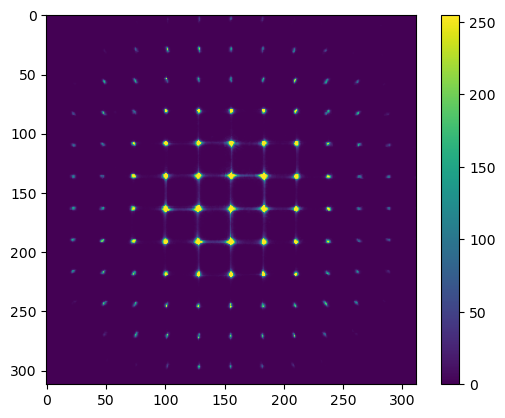

In [41]:
output = Path('2025-april')
take_images()

### correct the intrinsic tilt

In [51]:
def center_of_gravity(img):
    """
    Centroids of an image, or tensor of images.
    Centroids over the last 2 dimensions.

    Parameters:
        img (Tensor): (B, W, H)

    Returns:
        Tensor: Tensor of centroid values (B, 2)

    """
    # Ensure image is a 3D tensor
    assert len(img.shape) == 3, "Image should be 2D (B, W, H)"

    x_coords, y_coords = torch.arange(28).view(1, 1, 28).to(img.device), torch.arange(28, dtype=torch.float32).view(1, 28, 1).to(img.device)

    total_weight = img.sum(dim=[1, 2], keepdim=True)
    total_weight = torch.where(total_weight == 0, torch.tensor(float('nan')).to(img.device), total_weight)

    x_centroid = (img * x_coords).sum(dim=[1, 2], keepdim=True) / total_weight
    y_centroid = (img * y_coords).sum(dim=[1, 2], keepdim=True) / total_weight

    return torch.cat([x_centroid, y_centroid], dim=-1).squeeze()  # Shape: [B, 2]

def split_wfs_image(img):
    """
    Splits an image into its subapertures.
    Creates an view of a the input tensor. (121, 28, 28)

    Returns:
        Tensor: images of each subaperture.
    
    """

    img = v2.CenterCrop(308)(img)
    subaps = img.unfold(0, 28, 28).unfold(1, 28, 28)
    return subaps.contiguous().view(-1, 28, 28)

def centroids_to_slopes(centroids, reference):
    slopes = (centroids - reference) * 18 / 13800  # radian
    return torch.arcsin(slopes)

def calculate_mla_tt_misalignment(imgs, reference_positions):
    centroids = torch.zeros(len(imgs), 121, 2, device=device)
    for i, img in enumerate(imgs):
        subaps = split_wfs_image(img)
        centroids[i, :, :] = center_of_gravity(subaps)
    centroids = torch.mean(centroids, axis=0)
    slopes = centroids_to_slopes(centroids, reference_positions)
    # print(slopes.shape)
    return torch.sin(torch.mean(slopes, axis=0))*13800 # in microns  

def calculate_subaperture_positions(grid_size=11, subap_size=28):
    """
    Calculates the x, y pixel coordinates of all subapertures in the Shack-Hartmann grid.

    Args:
        grid_size (int): Number of subapertures along one dimension (e.g., 11x11 grid).
        subap_size (int): Size of each subaperture in pixels.

    Returns:
        Tensor: (grid_size^2, 2) array of x, y positions for each subaperture.
    """
    subap_centers = torch.arange(0, grid_size * subap_size, subap_size, device=device) + (subap_size / 2)-.5
    x, y = torch.meshgrid(subap_centers, subap_centers, indexing='xy')
    return torch.stack((x.flatten(), y.flatten()), dim=1)  # Shape: (grid_size^2, 2)

def calculate_rotational_misalignment(img, cam):
    assert len(img.shape) == 2, "Image should be 2D (W, H)"

    cog_y = np.array([center_of_gravity_np(img[2+28*i:28*(i+1)+2, 28*5+2:28*6+2]) for i in range(11)])
    cog_x = np.array([center_of_gravity_np(img[28*5+2:28*6+2, 2+28*i:28*(i+1)+2]) for i in range(11)])
    pitchs = np.array([28*i for i in [5, 4, 3, 2, 1, 0, -1, -2, -3, -4, -5]])

    cog_y[:, :] -= cog_y[5, :]
    cog_y[:, 1] += pitchs[:]

    cog_x[:, :] -= cog_x[5, :] 
    cog_x[:, 0] += pitchs[:]

    y = np.mean(np.vstack((cog_y[:, 0]*-1, cog_x[:, 1])), axis=0)
    yerr = np.std(np.vstack((cog_y[:, 0]*-1, cog_x[:, 1])), axis=0)
    yerr[5]=1e-9
    x = np.mean(np.vstack((cog_y[:, 1], cog_x[:, 0])), axis=0)

    def line(x, a):
        return a * x
    
    popt, pcov = curve_fit(line, x, y, sigma=yerr, p0=np.deg2rad(0.02))
    if pcov.squeeze() == np.inf:
        return calculate_rotational_misalignment(grab_frame(cam).squeeze(), cam)
    # plt.figure()
    # plt.scatter(cog_x[:, 0], cog_x[:, 1], label="horizontal")
    # plt.scatter(cog_y[:, 1]*-1, cog_y[:, 0], label="vertical")
    # plt.errorbar(x=x, y=y, yerr=yerr, fmt="o")
    # dom = np.linspace(x.min(), x.max(), 50)
    # plt.plot(dom, line(dom, *popt))
    # plt.legend()
    # plt.show()
    # print(f"Rotational misalignment = {np.rad2deg(np.arctan(popt[0]))} degrees")
    return np.arctan(popt[0])

def center_of_gravity_np(img):
 
    y_coords, x_coords = np.repeat(np.arange(28), 28).reshape(28, 28), np.transpose(np.repeat(np.arange(28), 28).reshape(28, 28))
    total_weight = np.sum(img)
    # aux= x_coords * img
    # print(aux.shape, np.sum(aux) / total_weight)
    # plt.imshow(aux.squeeze())
    # plt.show()
    x_centroid = np.sum((img * x_coords)) / total_weight
    y_centroid = np.sum((img * y_coords)) / total_weight

    return [x_centroid, y_centroid]

def calculate_reference(subap_positions, theta, deltas=torch.zeros(1, dtype=torch.float32)):
    """
    Calculates slopes by comparing centroids to rotated expected positions.

    Args:
        centroids (Tensor): Measured centroid positions (N^2, 2).
        subap_positions (Tensor): Subaperture positions in the Shack-Hartmann grid (N^2, 2).
        theta (float): Rotation angle of the lenslet array in radians.

    Returns:
        Tensor: Slopes in radians.
    """
    # Rotate subaperture positions
    cos_theta, sin_theta = np.cos(-theta), np.sin(-theta)
    rotation_matrix = torch.tensor([[cos_theta, -sin_theta], [sin_theta, cos_theta]], device=device, dtype=torch.float32)
    rotated_positions = (subap_positions @ rotation_matrix.T)
    # Calculate the expected centroids after accounting for rotation
    reference_centroids = rotated_positions - subap_positions + deltas.to(device)/18. + 13.5

    return reference_centroids

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
subap_positions = calculate_subaperture_positions(grid_size=11)

100%|██████████| 500/500 [00:45<00:00, 11.11it/s]


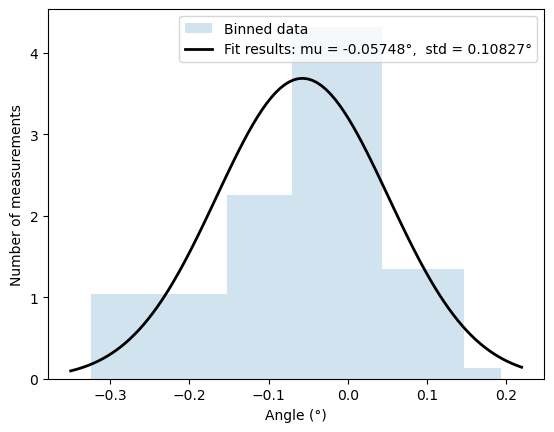

Final rotational misalignment = -0.057482581069560015 +- 0.10826601499272169


In [54]:
with VmbSystem.get_instance() as vmb:
    cams = vmb.get_all_cameras()
    with cams[0] as cam:
        # set parameters for wavefront sensor cmos
        set_camera_parameters(cam, t_exp=80)
        # grab a frame to correct for rotation mla
        thetas = np.array([calculate_rotational_misalignment(grab_frame(cam).squeeze(), cam) for i in tqdm(range(500))])
        thetas = thetas[~np.isnan(thetas)]
        theta = np.nanmean(thetas)
        theta_err = np.nanstd(thetas)
        plt.figure()
        hist(np.rad2deg(thetas), bins="blocks", histtype='stepfilled', alpha=0.2, density=True, label="Binned data")
        mu, std = norm.fit(np.rad2deg(thetas))
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        plt.plot(x, p, 'k', linewidth=2, label="Fit results: mu = %.5f°,  std = %.5f°" % (mu, std))
        plt.legend()
        plt.xlabel("Angle (°)")
        plt.ylabel("Number of measurements")
        plt.show()
        print(f"Final rotational misalignment = {np.rad2deg(theta)} +- {np.rad2deg(theta_err)}")
        reference_positions = calculate_reference(subap_positions, theta)


In [56]:
reference_positions.shape

torch.Size([121, 2])

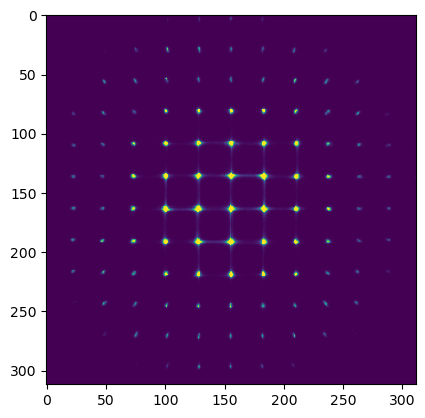

In [50]:
plt.imshow(a)